# Bayesian Workflow: Modeling Winning Time in Ultra-Trail Races

## Complete Bayesian Analysis

This notebook applies the full Bayesian workflow to model **Winning Time** of UTMB ultra-trail races. We follow the same structure as the original project (which modeled Mean Finish Time), comparing:

1. **Model 3**: Normal linear regression (baseline)
2. **Model 4**: Student-t linear regression (robust to outliers)

### Research Question

> How do race distance and elevation gain influence the **winning time** in ultra-trail races, and does a heavy-tailed model better capture the variability in elite performance?

### Workflow Steps

1. Problem Formulation & EDA
2. Model Specification & Prior Rationale
3. Prior Predictive Checks
4. Posterior Fitting (both models)
5. MCMC Diagnostics
6. Posterior Predictive Checks
7. Model Comparison (LOO-CV, WAIC)
8. Final Assessment

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
az.style.use('arviz-darkgrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Load processed data
df_full = pd.read_csv('utmb_processed.csv')
print(f"Full dataset: {df_full.shape[0]:,} rows x {df_full.shape[1]} columns")
print(f"\nWinning Time statistics:")
print(f"  Mean:     {df_full['Winning Time'].mean():.2f} h")
print(f"  Std:      {df_full['Winning Time'].std():.2f} h")
print(f"  Median:   {df_full['Winning Time'].median():.2f} h")
print(f"  Min:      {df_full['Winning Time'].min():.2f} h")
print(f"  Max:      {df_full['Winning Time'].max():.2f} h")
print(f"  Skewness: {df_full['Winning Time'].skew():.3f}")
print(f"  Kurtosis: {df_full['Winning Time'].kurtosis():.3f}")

Full dataset: 36,433 rows x 10 columns

Winning Time statistics:
  Mean:     7.02 h
  Std:      6.24 h
  Median:   4.94 h
  Min:      0.61 h
  Max:      49.99 h
  Skewness: 2.232
  Kurtosis: 6.412


## 1. Problem Formulation & Exploratory Data Analysis

**Winning Time** represents the fastest finish time in each race — the elite athlete's performance. Unlike Mean Finish Time (which reflects the average participant), Winning Time captures peak human performance under given course conditions.

Key characteristics:
- Continuous, positive, right-skewed (skewness ≈ 2.2, kurtosis ≈ 6.4)
- Strong linear relationship with distance (r ≈ 0.92) and elevation (r ≈ 0.81)
- Heavy tails suggest outlier races where even winners took unusually long

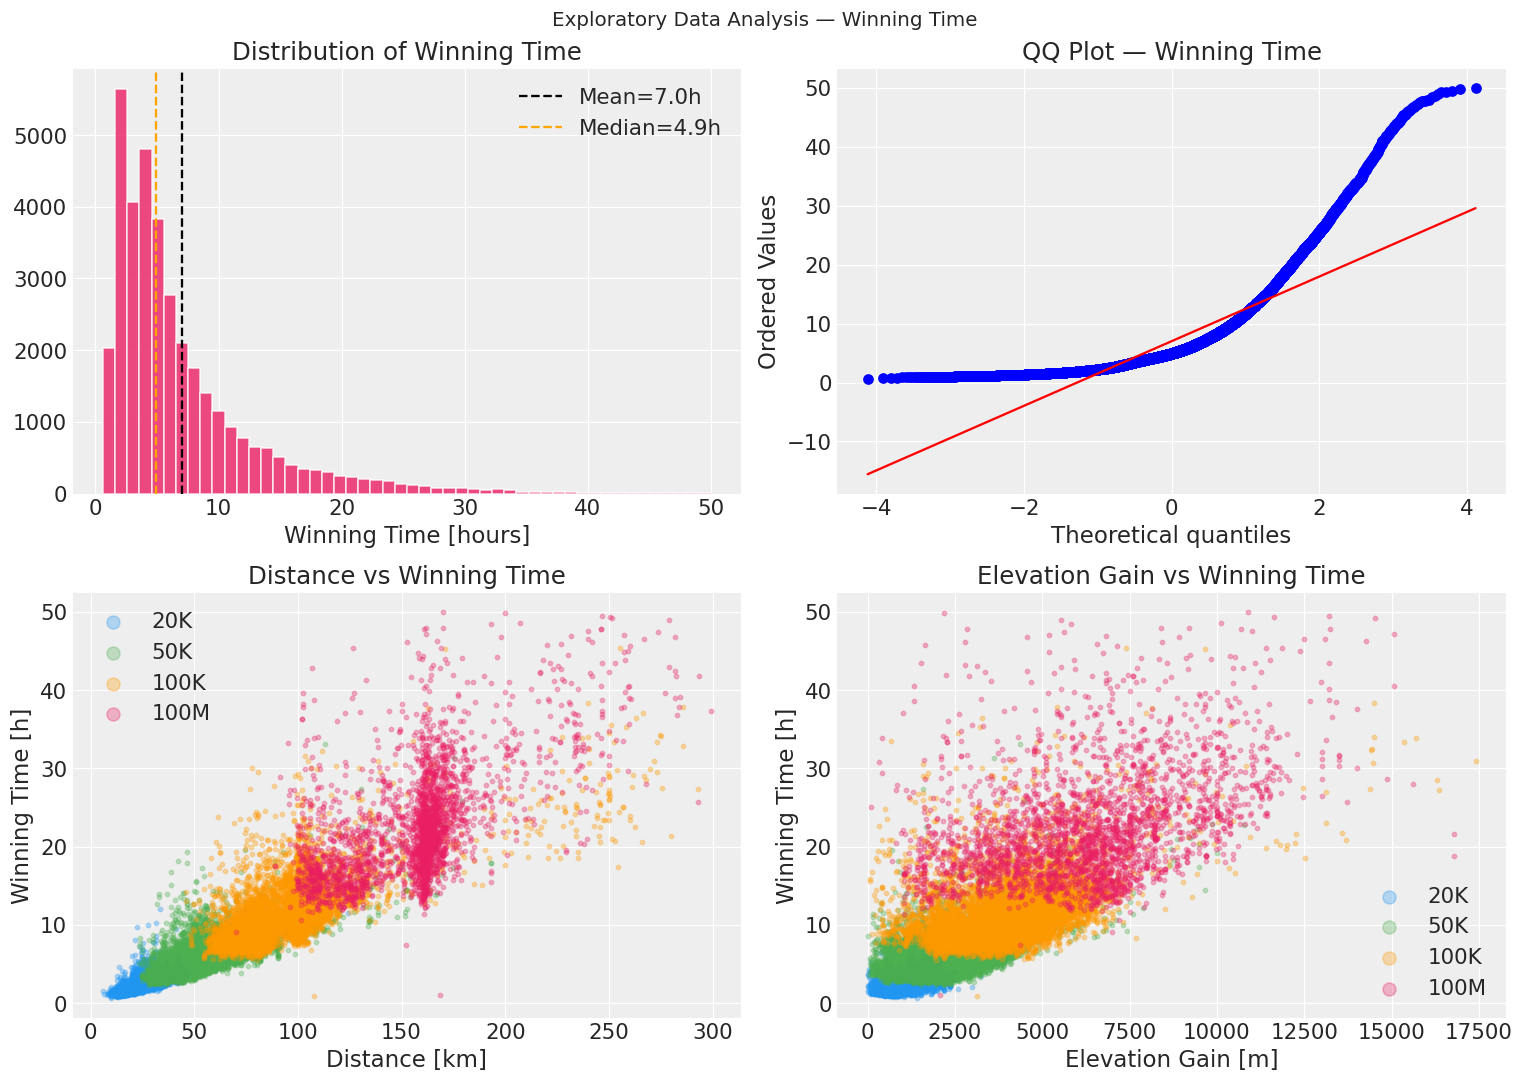


=== Winning Time by Race Category ===
  20K: mean=2.28h, std=0.82h, n=10765
  50K: mean=5.39h, std=1.90h, n=15487
  100K: mean=11.50h, std=4.04h, n=7391
  100M: mean=22.47h, std=7.03h, n=2790

=== Correlations ===
  Distance ↔ Winning Time:  r = 0.922
  Elevation ↔ Winning Time: r = 0.805


In [22]:
# EDA: Distribution and relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Winning Time distribution
axes[0,0].hist(df_full['Winning Time'], bins=50, color='#E91E63', edgecolor='white', alpha=0.8)
axes[0,0].axvline(df_full['Winning Time'].mean(), color='black', linestyle='--', 
                  label=f"Mean={df_full['Winning Time'].mean():.1f}h")
axes[0,0].axvline(df_full['Winning Time'].median(), color='orange', linestyle='--', 
                  label=f"Median={df_full['Winning Time'].median():.1f}h")
axes[0,0].set_xlabel('Winning Time [hours]')
axes[0,0].set_title('Distribution of Winning Time')
axes[0,0].legend()

# QQ plot
stats.probplot(df_full['Winning Time'], plot=axes[0,1])
axes[0,1].set_title('QQ Plot — Winning Time')

# Distance vs Winning Time
colors_cats = {'20K': '#2196F3', '50K': '#4CAF50', '100K': '#FF9800', '100M': '#E91E63'}
for cat in ['20K', '50K', '100K', '100M']:
    sub = df_full[df_full['Race Category'] == cat]
    axes[1,0].scatter(sub['Distance'], sub['Winning Time'], 
                      c=colors_cats[cat], alpha=0.3, s=8, label=cat)
axes[1,0].set_xlabel('Distance [km]')
axes[1,0].set_ylabel('Winning Time [h]')
axes[1,0].set_title('Distance vs Winning Time')
axes[1,0].legend(markerscale=3)

# Elevation vs Winning Time
for cat in ['20K', '50K', '100K', '100M']:
    sub = df_full[df_full['Race Category'] == cat]
    axes[1,1].scatter(sub['Elevation Gain'], sub['Winning Time'],
                      c=colors_cats[cat], alpha=0.3, s=8, label=cat)
axes[1,1].set_xlabel('Elevation Gain [m]')
axes[1,1].set_ylabel('Winning Time [h]')
axes[1,1].set_title('Elevation Gain vs Winning Time')
axes[1,1].legend(markerscale=3)

plt.suptitle('Exploratory Data Analysis — Winning Time', fontsize=13)
plt.tight_layout()
plt.savefig('fig_wt_01_eda.png', bbox_inches='tight')
plt.show()

# Winning time by category
print("\n=== Winning Time by Race Category ===")
for cat in ['20K', '50K', '100K', '100M']:
    sub = df_full[df_full['Race Category'] == cat]['Winning Time']
    print(f"  {cat}: mean={sub.mean():.2f}h, std={sub.std():.2f}h, n={len(sub)}")

print(f"\n=== Correlations ===")
print(f"  Distance ↔ Winning Time:  r = {df_full['Distance'].corr(df_full['Winning Time']):.3f}")
print(f"  Elevation ↔ Winning Time: r = {df_full['Elevation Gain'].corr(df_full['Winning Time']):.3f}")

## 2. Model Specification & Prior Rationale

### Model 3: Normal Linear Regression for Winning Time

$$y_i \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_{dist} \cdot \text{distance\_std}_i + \beta_{elev} \cdot \text{elevation\_std}_i$$

### Model 4: Student-t Linear Regression for Winning Time (Robust)

$$y_i \sim \text{Student-t}(\nu, \mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_{dist} \cdot \text{distance\_std}_i + \beta_{elev} \cdot \text{elevation\_std}_i$$

### Prior Selection

| Parameter | Prior | Rationale |
|-----------|-------|----------|
| $\alpha$ | Normal(7, 4) | Winning time at average distance/elevation ~7h |
| $\beta_{dist}$ | Normal(4, 2) | 1 SD distance (~40.5km) adds ~4h to winning time |
| $\beta_{elev}$ | Normal(1.5, 1.5) | 1 SD elevation (~1865m) adds ~1.5h |
| $\sigma$ | Exponential(0.3) | Residual SD, mean ~3.3h (less variability than mean finish time) |
| $\nu$ | Gamma(2, 0.1) | Degrees of freedom, mean=20, allows heavy tails |

**Key difference from Mean Finish Time priors**: Winning times are lower (~7h vs ~10.6h mean) with less residual variability, since elite athletes are more consistent. The effect of distance is proportionally larger because winning pace is faster.

## 3. Prior Predictive Checks

We simulate from the priors to verify they generate plausible winning time data.

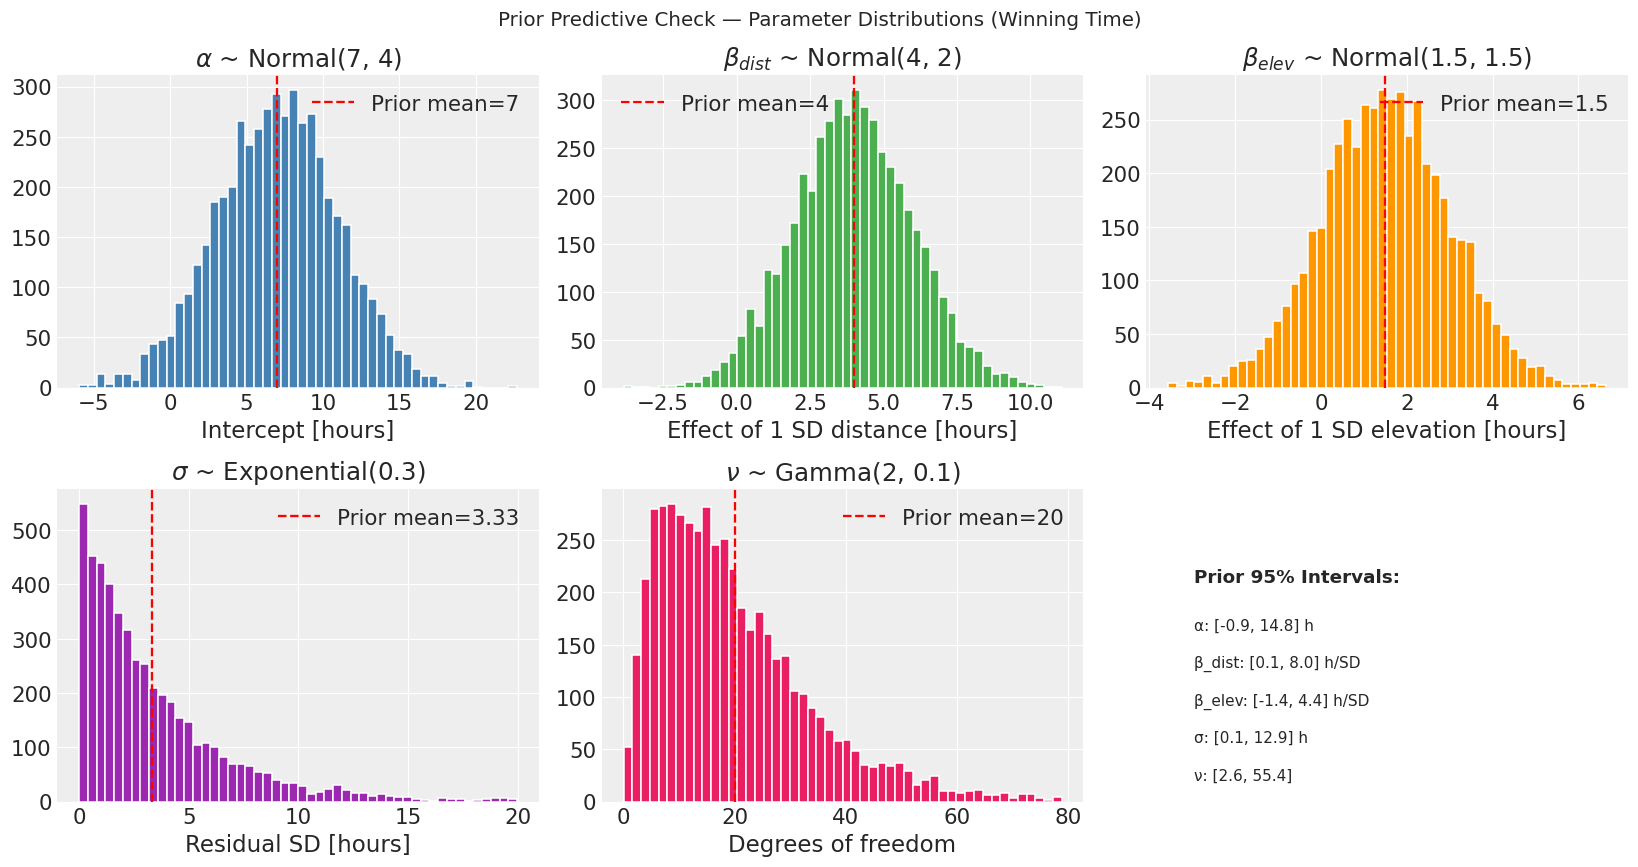

In [23]:
# Prior predictive simulation — parameter level
n_sim = 5000

alpha_sim = np.random.normal(7, 4, n_sim)
beta_dist_sim = np.random.normal(4, 2, n_sim)
beta_elev_sim = np.random.normal(1.5, 1.5, n_sim)
sigma_sim = np.random.exponential(1/0.3, n_sim)  # Exponential(rate=0.3) => mean=3.33
nu_sim = np.random.gamma(2, 1/0.1, n_sim)  # Gamma(shape=2, rate=0.1) => mean=20

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].hist(alpha_sim, bins=50, color='steelblue', edgecolor='white')
axes[0,0].axvline(7, color='red', linestyle='--', label='Prior mean=7')
axes[0,0].set_title(r'$\alpha$ ~ Normal(7, 4)')
axes[0,0].set_xlabel('Intercept [hours]')
axes[0,0].legend()

axes[0,1].hist(beta_dist_sim, bins=50, color='#4CAF50', edgecolor='white')
axes[0,1].axvline(4, color='red', linestyle='--', label='Prior mean=4')
axes[0,1].set_title(r'$\beta_{dist}$ ~ Normal(4, 2)')
axes[0,1].set_xlabel('Effect of 1 SD distance [hours]')
axes[0,1].legend()

axes[0,2].hist(beta_elev_sim, bins=50, color='#FF9800', edgecolor='white')
axes[0,2].axvline(1.5, color='red', linestyle='--', label='Prior mean=1.5')
axes[0,2].set_title(r'$\beta_{elev}$ ~ Normal(1.5, 1.5)')
axes[0,2].set_xlabel('Effect of 1 SD elevation [hours]')
axes[0,2].legend()

axes[1,0].hist(sigma_sim[sigma_sim < 20], bins=50, color='#9C27B0', edgecolor='white')
axes[1,0].axvline(3.33, color='red', linestyle='--', label='Prior mean=3.33')
axes[1,0].set_title(r'$\sigma$ ~ Exponential(0.3)')
axes[1,0].set_xlabel('Residual SD [hours]')
axes[1,0].legend()

axes[1,1].hist(nu_sim[nu_sim < 80], bins=50, color='#E91E63', edgecolor='white')
axes[1,1].axvline(20, color='red', linestyle='--', label='Prior mean=20')
axes[1,1].set_title(r'$\nu$ ~ Gamma(2, 0.1)')
axes[1,1].set_xlabel('Degrees of freedom')
axes[1,1].legend()

axes[1,2].axis('off')
axes[1,2].text(0.1, 0.7, 'Prior 95% Intervals:', fontsize=12, fontweight='bold', transform=axes[1,2].transAxes)
axes[1,2].text(0.1, 0.55, f'α: [{np.percentile(alpha_sim, 2.5):.1f}, {np.percentile(alpha_sim, 97.5):.1f}] h', fontsize=10, transform=axes[1,2].transAxes)
axes[1,2].text(0.1, 0.43, f'β_dist: [{np.percentile(beta_dist_sim, 2.5):.1f}, {np.percentile(beta_dist_sim, 97.5):.1f}] h/SD', fontsize=10, transform=axes[1,2].transAxes)
axes[1,2].text(0.1, 0.31, f'β_elev: [{np.percentile(beta_elev_sim, 2.5):.1f}, {np.percentile(beta_elev_sim, 97.5):.1f}] h/SD', fontsize=10, transform=axes[1,2].transAxes)
axes[1,2].text(0.1, 0.19, f'σ: [{np.percentile(sigma_sim, 2.5):.1f}, {np.percentile(sigma_sim, 97.5):.1f}] h', fontsize=10, transform=axes[1,2].transAxes)
axes[1,2].text(0.1, 0.07, f'ν: [{np.percentile(nu_sim, 2.5):.1f}, {np.percentile(nu_sim, 97.5):.1f}]', fontsize=10, transform=axes[1,2].transAxes)

plt.suptitle('Prior Predictive Check — Parameter Distributions (Winning Time)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_wt_02_prior_parameters.png', bbox_inches='tight')
plt.show()

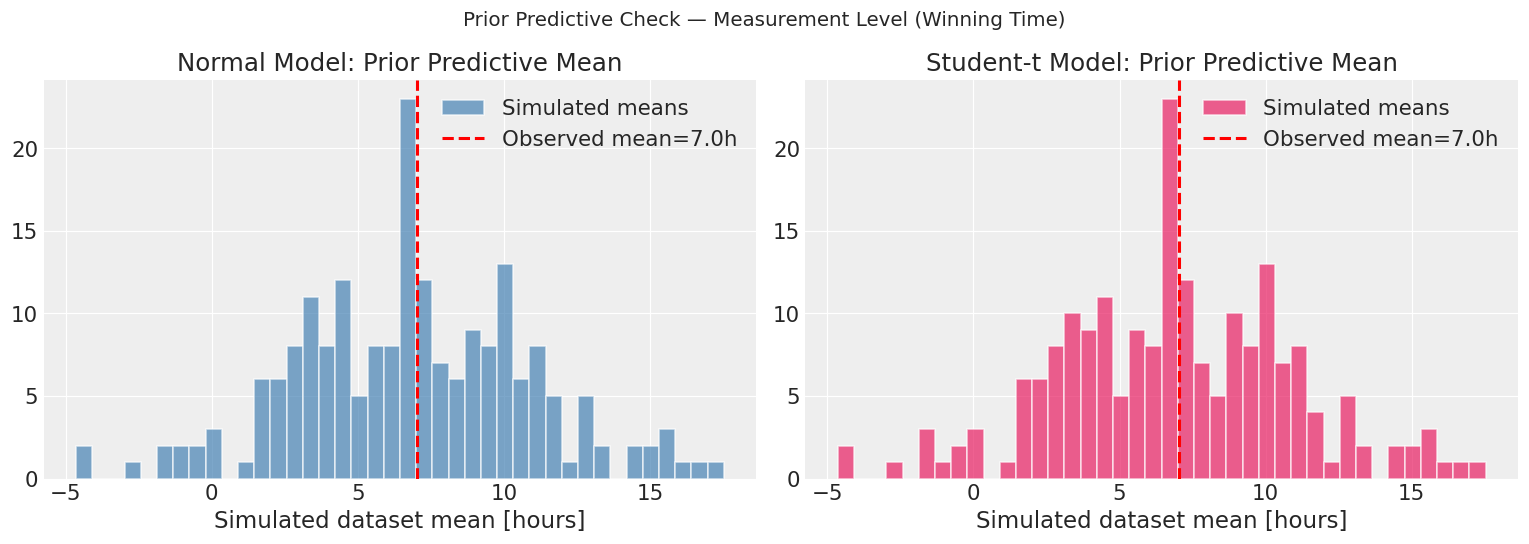

Observed Winning Time mean: 7.02h
Normal prior pred. mean 95% CI: [-1.2, 15.6]
Student-t prior pred. mean 95% CI: [-1.4, 15.6]

→ Observed mean falls within prior predictive range — priors are compatible with data.


In [4]:
# Prior predictive simulation — measurement level
dist_vals = df_full['distance_std'].values
elev_vals = df_full['elevation_std'].values
y_obs_full = df_full['Winning Time'].values

n_prior_sims = 200
N_full = len(dist_vals)
y_prior_normal = np.zeros((n_prior_sims, N_full))
y_prior_studentt = np.zeros((n_prior_sims, N_full))

for s in range(n_prior_sims):
    a = np.random.normal(7, 4)
    bd = np.random.normal(4, 2)
    be = np.random.normal(1.5, 1.5)
    sig = np.random.exponential(1/0.3)
    nu = max(1.1, np.random.gamma(2, 1/0.1))
    
    mu = a + bd * dist_vals + be * elev_vals
    y_prior_normal[s] = np.random.normal(mu, sig)
    y_prior_studentt[s] = stats.t.rvs(df=nu, loc=mu, scale=sig)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prior_means_normal = y_prior_normal.mean(axis=1)
axes[0].hist(prior_means_normal, bins=40, color='steelblue', alpha=0.7, edgecolor='white', label='Simulated means')
axes[0].axvline(y_obs_full.mean(), color='red', linewidth=2, linestyle='--', label=f'Observed mean={y_obs_full.mean():.1f}h')
axes[0].set_title('Normal Model: Prior Predictive Mean')
axes[0].set_xlabel('Simulated dataset mean [hours]')
axes[0].legend()

prior_means_t = y_prior_studentt.mean(axis=1)
axes[1].hist(prior_means_t[np.abs(prior_means_t) < 50], bins=40, color='#E91E63', alpha=0.7, edgecolor='white', label='Simulated means')
axes[1].axvline(y_obs_full.mean(), color='red', linewidth=2, linestyle='--', label=f'Observed mean={y_obs_full.mean():.1f}h')
axes[1].set_title('Student-t Model: Prior Predictive Mean')
axes[1].set_xlabel('Simulated dataset mean [hours]')
axes[1].legend()

plt.suptitle('Prior Predictive Check — Measurement Level (Winning Time)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_wt_03_prior_predictive.png', bbox_inches='tight')
plt.show()

print(f"Observed Winning Time mean: {y_obs_full.mean():.2f}h")
print(f"Normal prior pred. mean 95% CI: [{np.percentile(prior_means_normal, 2.5):.1f}, {np.percentile(prior_means_normal, 97.5):.1f}]")
print(f"Student-t prior pred. mean 95% CI: [{np.percentile(prior_means_t, 2.5):.1f}, {np.percentile(prior_means_t, 97.5):.1f}]")
print(f"\n→ Observed mean falls within prior predictive range — priors are compatible with data.")

## 4. Posterior Fitting

We now fit both models using CmdStanPy. We subsample to 5,000 observations for computational feasibility (same approach as the original project).

In [25]:
# Subsample for computational feasibility
df = df_full.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Subsample: {df.shape[0]:,} observations (from {df_full.shape[0]:,})")
print(f"Categories: {df['Race Category'].value_counts().to_dict()}")

# Prepare Stan data
stan_data = {
    'N': len(df),
    'y': df['Winning Time'].values.tolist(),
    'distance_std': df['distance_std'].values.tolist(),
    'elevation_std': df['elevation_std'].values.tolist()
}

print(f"\nStan data prepared:")
print(f"  N = {stan_data['N']}")
print(f"  y (Winning Time) range: [{min(stan_data['y']):.2f}, {max(stan_data['y']):.2f}] hours")

Subsample: 5,000 observations (from 36,433)
Categories: {'50K': 2101, '20K': 1503, '100K': 1016, '100M': 380}

Stan data prepared:
  N = 5000
  y (Winning Time) range: [0.77, 48.45] hours


In [6]:
# Compile and fit Model 3 (Normal)
model3 = CmdStanModel(stan_file='model3_winning_normal.stan')
print("Model 3 (Normal — Winning Time) compiled.")

fit3 = model3.sample(
    data=stan_data,
    chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    seed=42,
    show_progress=True
)
print("Model 3 sampling complete.")

21:32:29 - cmdstanpy - INFO - compiling stan file /workspace/project/model3_winning_normal.stan to exe file /workspace/project/model3_winning_normal
21:33:02 - cmdstanpy - INFO - compiled model executable: /workspace/project/model3_winning_normal
21:33:02 - cmdstanpy - INFO - CmdStan start processing


Model 3 (Normal — Winning Time) compiled.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

21:33:13 - cmdstanpy - INFO - CmdStan done processing.



Model 3 sampling complete.


In [7]:
# Compile and fit Model 4 (Student-t)
model4 = CmdStanModel(stan_file='model4_winning_student_t.stan')
print("Model 4 (Student-t — Winning Time) compiled.")

fit4 = model4.sample(
    data=stan_data,
    chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    seed=42,
    show_progress=True
)
print("Model 4 sampling complete.")

21:33:24 - cmdstanpy - INFO - compiling stan file /workspace/project/model4_winning_student_t.stan to exe file /workspace/project/model4_winning_student_t
21:33:45 - cmdstanpy - INFO - compiled model executable: /workspace/project/model4_winning_student_t
21:33:45 - cmdstanpy - INFO - CmdStan start processing


Model 4 (Student-t — Winning Time) compiled.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

21:34:01 - cmdstanpy - INFO - CmdStan done processing.
21:34:01 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model4_winning_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model4_winning_student_t.stan', line 30, column 2 to column 89)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'model4_winning_student_t.stan', line 27, column 2 to column 21)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model4_winning_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model4_winning_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model4_winning_student_t.stan', line 30, column 2


Model 4 sampling complete.


## 5. MCMC Diagnostics

We verify convergence for both models: R-hat < 1.01, ESS > 400, no divergences, well-mixed trace plots.

In [8]:
# Convert to ArviZ InferenceData
idata3 = az.from_cmdstanpy(
    fit3,
    posterior_predictive='y_rep',
    log_likelihood='log_lik',
    observed_data={'y': df['Winning Time'].values}
)

idata4 = az.from_cmdstanpy(
    fit4,
    posterior_predictive='y_rep',
    log_likelihood='log_lik',
    observed_data={'y': df['Winning Time'].values}
)

# Model 3 summary
print("=" * 70)
print("MODEL 3 (Normal — Winning Time) — Posterior Summary")
print("=" * 70)
summary3 = az.summary(idata3, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma'])
print(summary3.to_string())

print("\n")

# Model 4 summary
print("=" * 70)
print("MODEL 4 (Student-t — Winning Time) — Posterior Summary")
print("=" * 70)
summary4 = az.summary(idata4, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'])
print(summary4.to_string())

MODEL 3 (Normal — Winning Time) — Posterior Summary
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha      7.018  0.030   6.964    7.077      0.000    0.000    3833.0    2575.0    1.0
beta_dist  4.361  0.046   4.269    4.442      0.001    0.001    2374.0    2822.0    1.0
beta_elev  1.862  0.044   1.784    1.945      0.001    0.001    2532.0    2448.0    1.0
sigma      2.126  0.021   2.087    2.165      0.000    0.000    3943.0    2962.0    1.0


MODEL 4 (Student-t — Winning Time) — Posterior Summary
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha      6.402  0.017   6.371    6.434      0.000    0.000    2642.0    2494.0    1.0
beta_dist  3.634  0.028   3.579    3.686      0.001    0.000    2205.0    2449.0    1.0
beta_elev  1.426  0.026   1.379    1.479      0.001    0.000    2288.0    2293.0    1.0
sigma      0.563  0.013   0.538    0.589      0.000    0.000    2378.0    2695.0    1.0
nu         

In [9]:
# Diagnostics check for both models
print("=" * 70)
print("MCMC DIAGNOSTICS")
print("=" * 70)

for name, summary, fit in [("Model 3 (Normal)", summary3, fit3), ("Model 4 (Student-t)", summary4, fit4)]:
    print(f"\n--- {name} ---")
    rhat_vals = summary['r_hat'].values
    ess_bulk_vals = summary['ess_bulk'].values
    ess_tail_vals = summary['ess_tail'].values
    
    print(f"  R-hat values:")
    for param, rhat in zip(summary.index, rhat_vals):
        status = '✓' if rhat < 1.01 else '✗ WARNING'
        print(f"    {param}: {rhat:.4f} {status}")
    
    print(f"  ESS bulk (min): {ess_bulk_vals.min():.0f} {'✓' if ess_bulk_vals.min() > 400 else '✗ WARNING'}")
    print(f"  ESS tail (min): {ess_tail_vals.min():.0f} {'✓' if ess_tail_vals.min() > 400 else '✗ WARNING'}")
    print(f"  All R-hat < 1.01: {all(rhat_vals < 1.01)}")
    print(f"  All ESS > 400: {all(ess_bulk_vals > 400) and all(ess_tail_vals > 400)}")

print("\n\n--- Stan Diagnostics (Model 3) ---")
print(fit3.diagnose())
print("\n--- Stan Diagnostics (Model 4) ---")
print(fit4.diagnose())

MCMC DIAGNOSTICS

--- Model 3 (Normal) ---
  R-hat values:
    alpha: 1.0000 ✓
    beta_dist: 1.0000 ✓
    beta_elev: 1.0000 ✓
    sigma: 1.0000 ✓
  ESS bulk (min): 2374 ✓
  ESS tail (min): 2448 ✓
  All R-hat < 1.01: True
  All ESS > 400: True

--- Model 4 (Student-t) ---
  R-hat values:
    alpha: 1.0000 ✓
    beta_dist: 1.0000 ✓
    beta_elev: 1.0000 ✓
    sigma: 1.0000 ✓
    nu: 1.0000 ✓
  ESS bulk (min): 2205 ✓
  ESS tail (min): 2293 ✓
  All R-hat < 1.01: True
  All ESS > 400: True


--- Stan Diagnostics (Model 3) ---
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


--- Stan Diagnostics (Model 4) ---

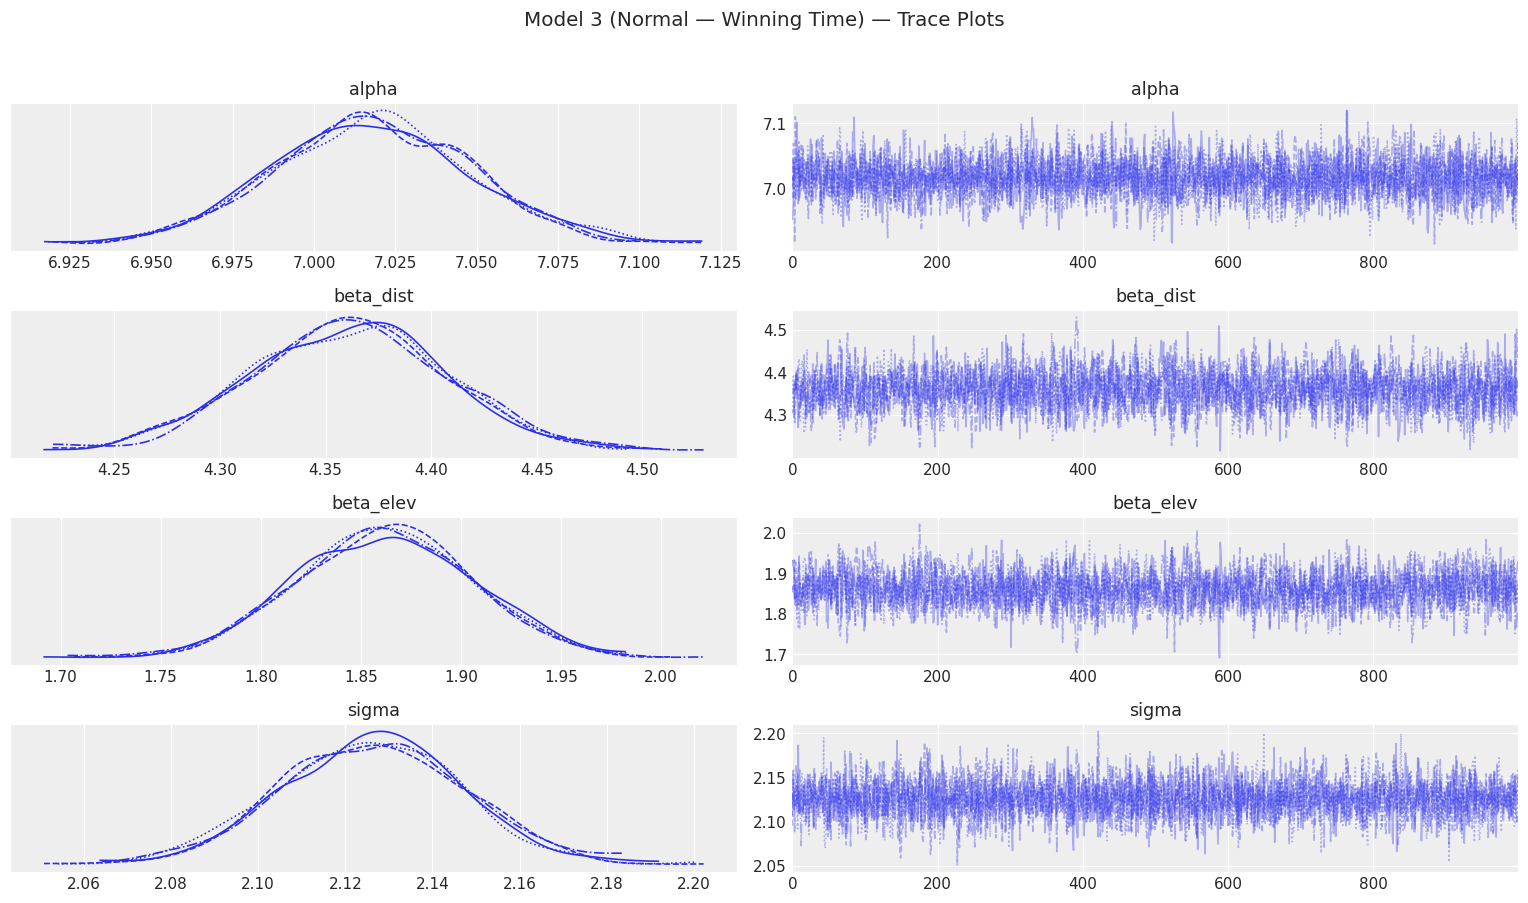

In [10]:
# Trace plots — Model 3
fig = az.plot_trace(idata3, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma'],
                    figsize=(14, 8), compact=True)
plt.suptitle('Model 3 (Normal — Winning Time) — Trace Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_wt_04_model3_trace.png', bbox_inches='tight')
plt.show()

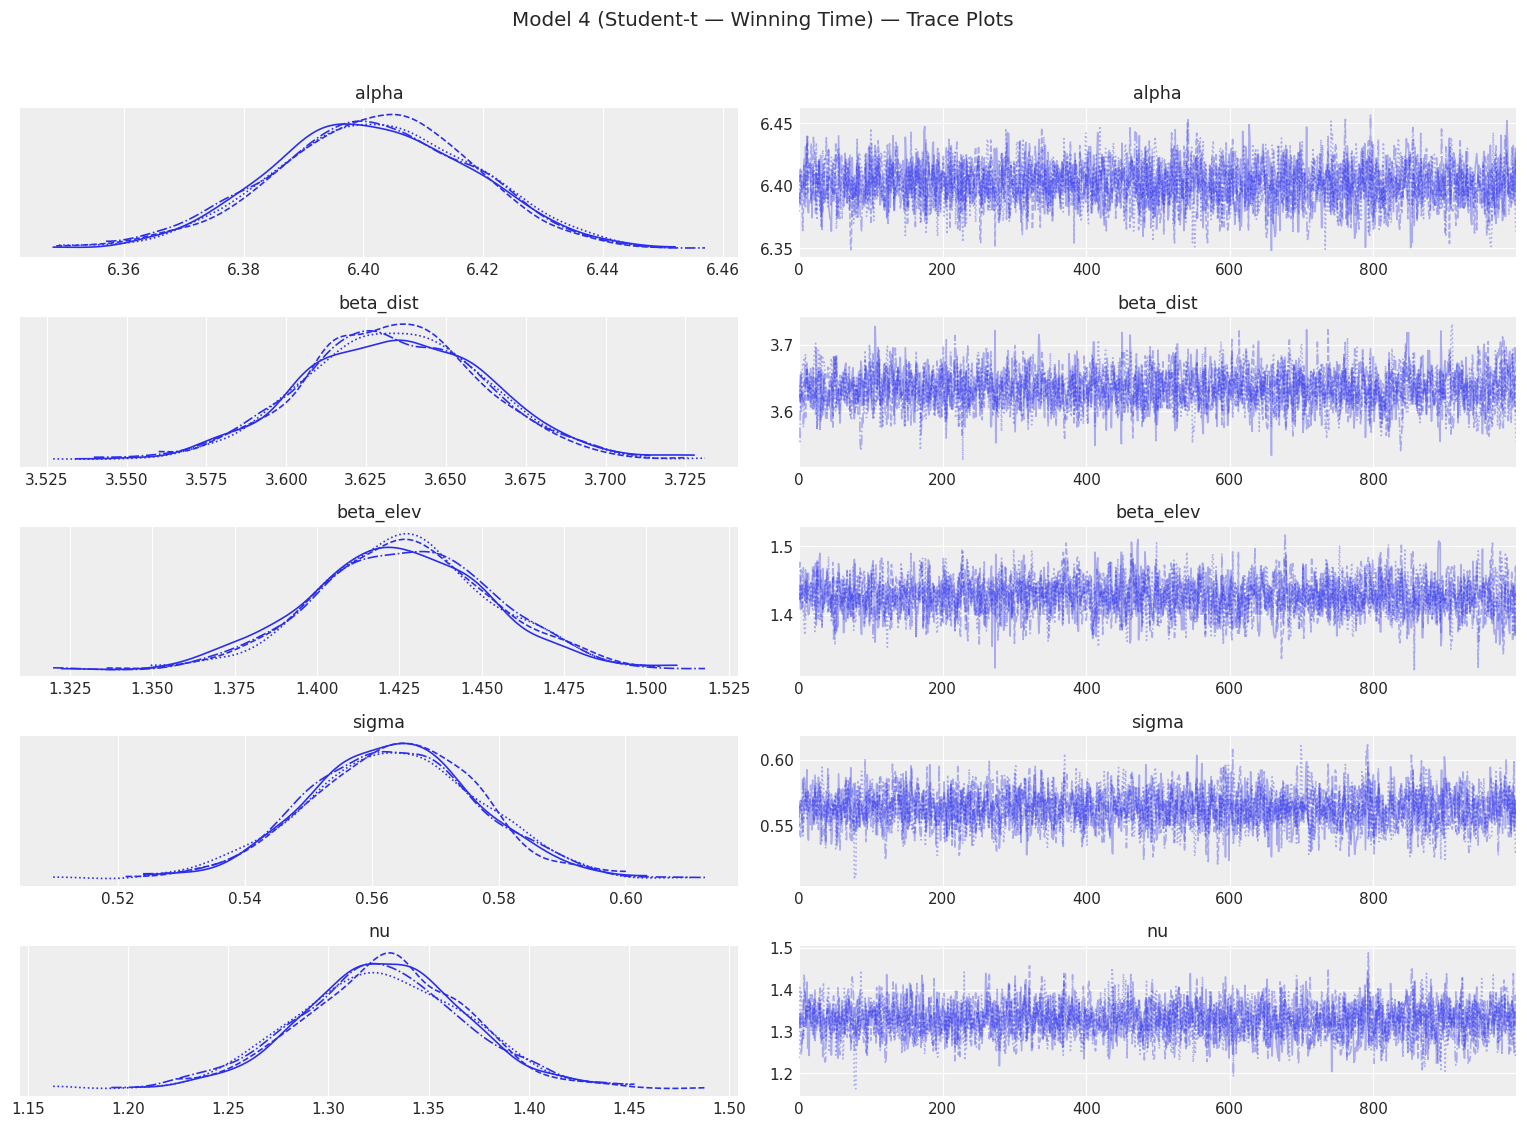

In [11]:
# Trace plots — Model 4
fig = az.plot_trace(idata4, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'],
                    figsize=(14, 10), compact=True)
plt.suptitle('Model 4 (Student-t — Winning Time) — Trace Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_wt_05_model4_trace.png', bbox_inches='tight')
plt.show()

## 6. Posterior Predictive Checks

We verify that the fitted models can reproduce the observed winning time data.

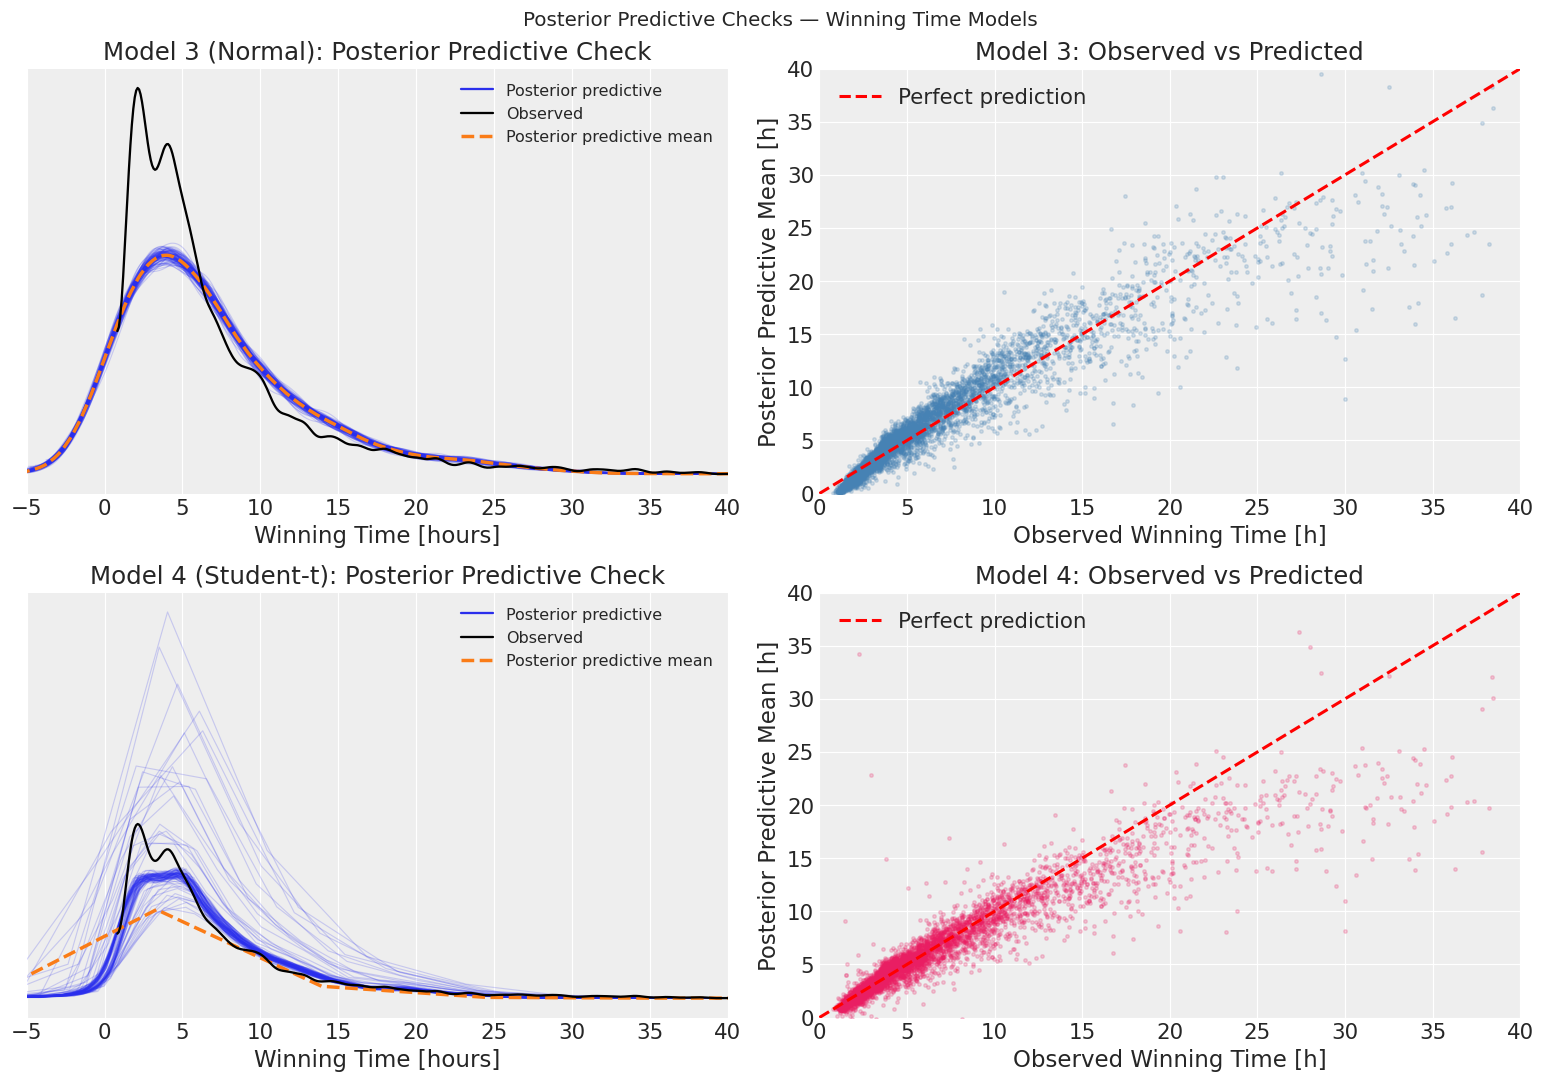

In [12]:
# PPC — Overall comparison (both models)
y_obs = df['Winning Time'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model 3 PPC density
az.plot_ppc(idata3, data_pairs={'y': 'y_rep'}, num_pp_samples=100, ax=axes[0,0])
axes[0,0].set_title('Model 3 (Normal): Posterior Predictive Check')
axes[0,0].set_xlabel('Winning Time [hours]')
axes[0,0].set_xlim(-5, 40)

# Model 3 observed vs predicted
y_rep3_mean = idata3.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs)).mean(axis=0)
axes[0,1].scatter(y_obs, y_rep3_mean, alpha=0.2, s=5, color='steelblue')
axes[0,1].plot([0, 40], [0, 40], 'r--', linewidth=2, label='Perfect prediction')
axes[0,1].set_xlabel('Observed Winning Time [h]')
axes[0,1].set_ylabel('Posterior Predictive Mean [h]')
axes[0,1].set_title('Model 3: Observed vs Predicted')
axes[0,1].legend()
axes[0,1].set_xlim(0, 40)
axes[0,1].set_ylim(0, 40)

# Model 4 PPC density
az.plot_ppc(idata4, data_pairs={'y': 'y_rep'}, num_pp_samples=100, ax=axes[1,0])
axes[1,0].set_title('Model 4 (Student-t): Posterior Predictive Check')
axes[1,0].set_xlabel('Winning Time [hours]')
axes[1,0].set_xlim(-5, 40)

# Model 4 observed vs predicted
y_rep4_mean = idata4.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs)).mean(axis=0)
axes[1,1].scatter(y_obs, y_rep4_mean, alpha=0.2, s=5, color='#E91E63')
axes[1,1].plot([0, 40], [0, 40], 'r--', linewidth=2, label='Perfect prediction')
axes[1,1].set_xlabel('Observed Winning Time [h]')
axes[1,1].set_ylabel('Posterior Predictive Mean [h]')
axes[1,1].set_title('Model 4: Observed vs Predicted')
axes[1,1].legend()
axes[1,1].set_xlim(0, 40)
axes[1,1].set_ylim(0, 40)

plt.suptitle('Posterior Predictive Checks — Winning Time Models', fontsize=13)
plt.tight_layout()
plt.savefig('fig_wt_06_ppc_overall.png', bbox_inches='tight')
plt.show()

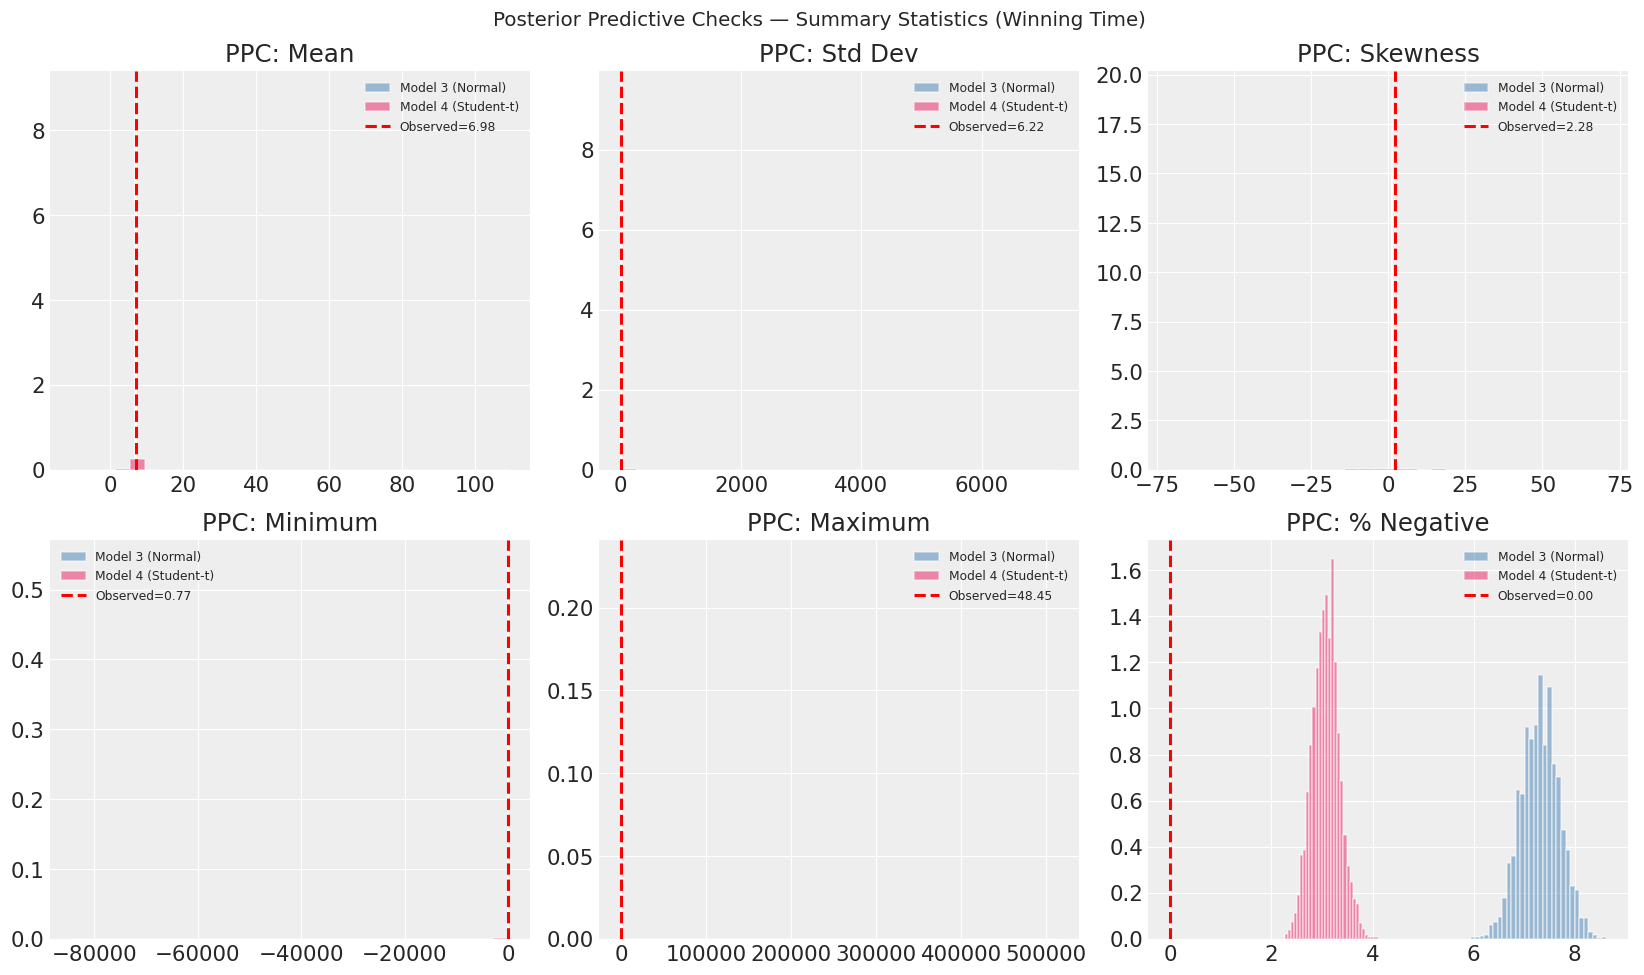

In [ ]:
# PPC — Summary statistics comparison
# Note: With ν≈1.3, the Student-t generates extreme values. We use robust statistics
# and clip replications to meaningful ranges for visualization.
y_rep3_samples = idata3.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs))
y_rep4_samples = idata4.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs))

# Clip Student-t replications to a sensible range for computing display statistics
# (raw values can be ±millions with ν≈1.3, which distorts everything)
y_rep4_clipped = np.clip(y_rep4_samples, -100, 200)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Mean (robust to outliers since it averages over 5000 obs)
pp_means3 = y_rep3_samples.mean(axis=1)
pp_means4 = y_rep4_clipped.mean(axis=1)
axes[0,0].hist(pp_means3, bins=30, alpha=0.6, color='steelblue', edgecolor='white', label='Model 3 (Normal)', density=True)
axes[0,0].hist(pp_means4, bins=30, alpha=0.6, color='#E91E63', edgecolor='white', label='Model 4 (Student-t)', density=True)
axes[0,0].axvline(y_obs.mean(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.mean():.2f}')
axes[0,0].set_title('PPC: Mean')
axes[0,0].set_xlabel('Mean [hours]')
axes[0,0].legend(fontsize=8)

# Median (robust to extreme tails)
pp_med3 = np.median(y_rep3_samples, axis=1)
pp_med4 = np.median(y_rep4_samples, axis=1)
axes[0,1].hist(pp_med3, bins=30, alpha=0.6, color='steelblue', edgecolor='white', label='Model 3 (Normal)', density=True)
axes[0,1].hist(pp_med4, bins=30, alpha=0.6, color='#E91E63', edgecolor='white', label='Model 4 (Student-t)', density=True)
axes[0,1].axvline(np.median(y_obs), color='red', linewidth=2, linestyle='--', label=f'Observed={np.median(y_obs):.2f}')
axes[0,1].set_title('PPC: Median')
axes[0,1].set_xlabel('Median [hours]')
axes[0,1].legend(fontsize=8)

# IQR (interquartile range — robust scale measure)
pp_iqr3 = np.percentile(y_rep3_samples, 75, axis=1) - np.percentile(y_rep3_samples, 25, axis=1)
pp_iqr4 = np.percentile(y_rep4_samples, 75, axis=1) - np.percentile(y_rep4_samples, 25, axis=1)
obs_iqr = np.percentile(y_obs, 75) - np.percentile(y_obs, 25)
axes[0,2].hist(pp_iqr3, bins=30, alpha=0.6, color='steelblue', edgecolor='white', label='Model 3 (Normal)', density=True)
axes[0,2].hist(pp_iqr4, bins=30, alpha=0.6, color='#E91E63', edgecolor='white', label='Model 4 (Student-t)', density=True)
axes[0,2].axvline(obs_iqr, color='red', linewidth=2, linestyle='--', label=f'Observed={obs_iqr:.2f}')
axes[0,2].set_title('PPC: IQR (robust spread)')
axes[0,2].set_xlabel('IQR [hours]')
axes[0,2].legend(fontsize=8)

# 90th percentile
pp_p90_3 = np.percentile(y_rep3_samples, 90, axis=1)
pp_p90_4 = np.percentile(y_rep4_samples, 90, axis=1)
obs_p90 = np.percentile(y_obs, 90)
axes[1,0].hist(pp_p90_3, bins=30, alpha=0.6, color='steelblue', edgecolor='white', label='Model 3 (Normal)', density=True)
axes[1,0].hist(pp_p90_4, bins=30, alpha=0.6, color='#E91E63', edgecolor='white', label='Model 4 (Student-t)', density=True)
axes[1,0].axvline(obs_p90, color='red', linewidth=2, linestyle='--', label=f'Observed={obs_p90:.2f}')
axes[1,0].set_title('PPC: 90th Percentile')
axes[1,0].set_xlabel('P90 [hours]')
axes[1,0].legend(fontsize=8)

# 10th percentile
pp_p10_3 = np.percentile(y_rep3_samples, 10, axis=1)
pp_p10_4 = np.percentile(y_rep4_samples, 10, axis=1)
obs_p10 = np.percentile(y_obs, 10)
axes[1,1].hist(pp_p10_3, bins=30, alpha=0.6, color='steelblue', edgecolor='white', label='Model 3 (Normal)', density=True)
axes[1,1].hist(pp_p10_4, bins=30, alpha=0.6, color='#E91E63', edgecolor='white', label='Model 4 (Student-t)', density=True)
axes[1,1].axvline(obs_p10, color='red', linewidth=2, linestyle='--', label=f'Observed={obs_p10:.2f}')
axes[1,1].set_title('PPC: 10th Percentile')
axes[1,1].set_xlabel('P10 [hours]')
axes[1,1].legend(fontsize=8)

# Proportion within observed range
pp_in_range3 = ((y_rep3_samples >= 0) & (y_rep3_samples <= 60)).mean(axis=1) * 100
pp_in_range4 = ((y_rep4_samples >= 0) & (y_rep4_samples <= 60)).mean(axis=1) * 100
obs_in_range = ((y_obs >= 0) & (y_obs <= 60)).mean() * 100
axes[1,2].hist(pp_in_range3, bins=30, alpha=0.6, color='steelblue', edgecolor='white', label='Model 3 (Normal)', density=True)
axes[1,2].hist(pp_in_range4, bins=30, alpha=0.6, color='#E91E63', edgecolor='white', label='Model 4 (Student-t)', density=True)
axes[1,2].axvline(obs_in_range, color='red', linewidth=2, linestyle='--', label=f'Observed={obs_in_range:.1f}%')
axes[1,2].set_title('PPC: % in [0, 60]h range')
axes[1,2].set_xlabel('% observations in plausible range')
axes[1,2].legend(fontsize=8)

plt.suptitle('Posterior Predictive Checks — Robust Summary Statistics (Winning Time)\n(Using quantile-based statistics robust to ν≈1.3 heavy tails)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_wt_07_ppc_stats.png', dpi=150, bbox_inches='tight')
plt.show()

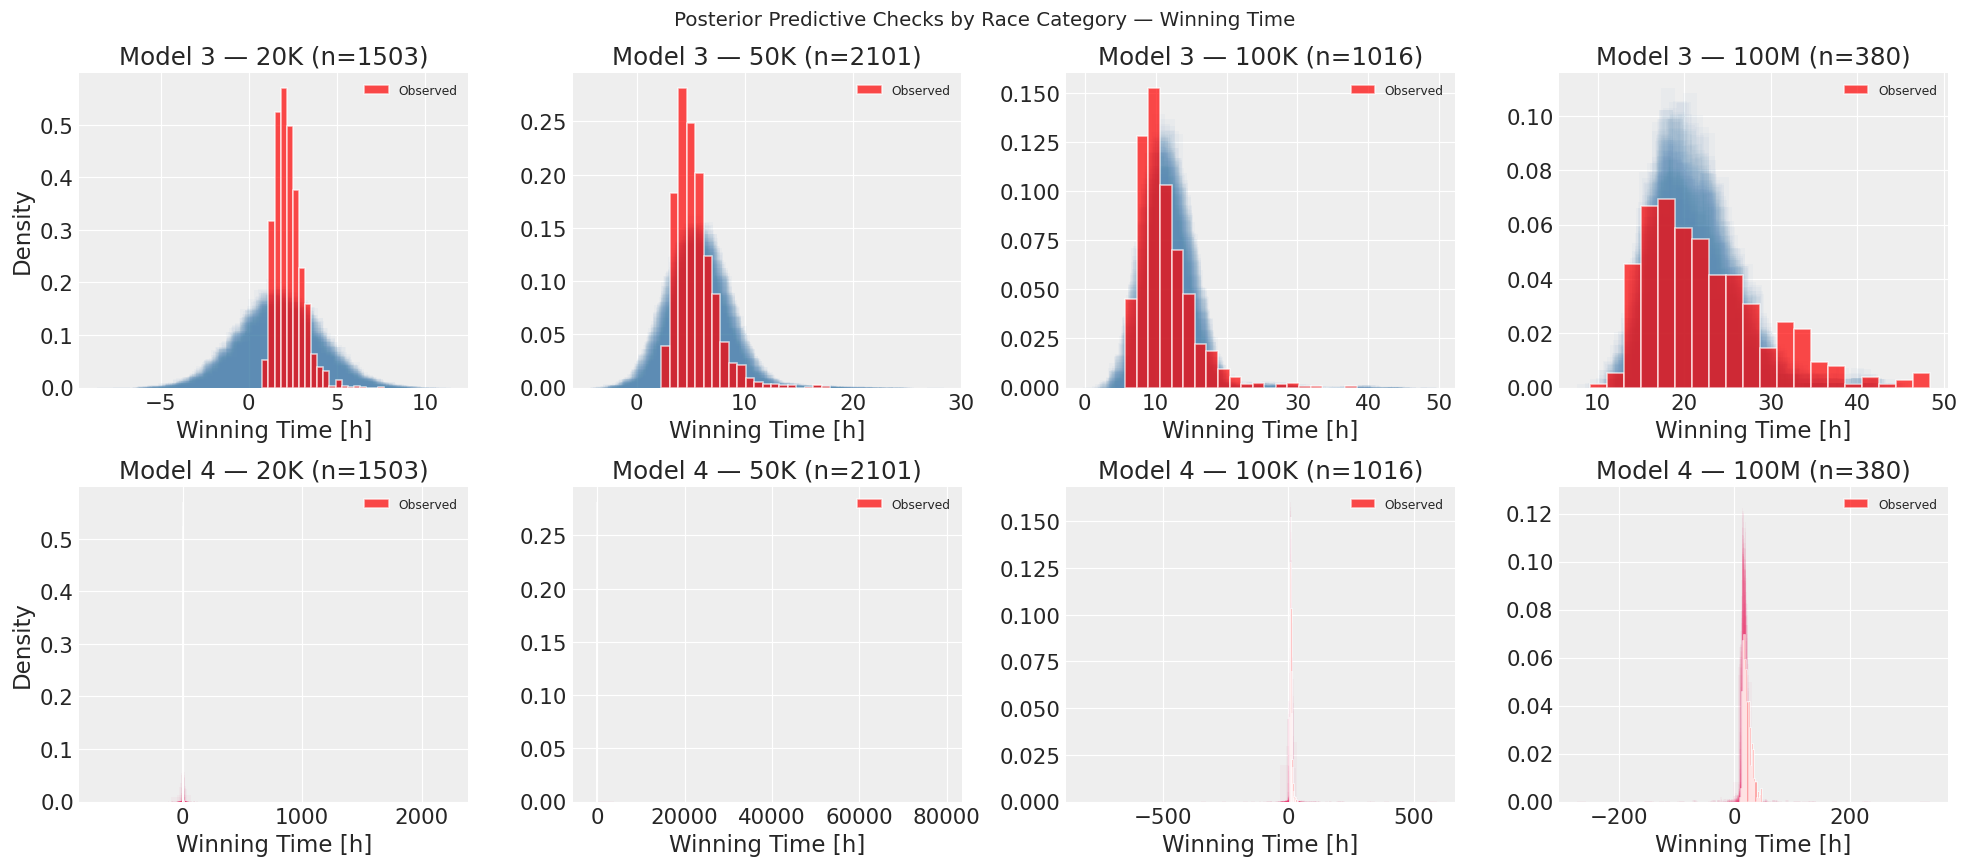

In [ ]:
# PPC by race category — with proper clipping for Student-t extreme tails
from scipy.stats import gaussian_kde

categories = ['20K', '50K', '100K', '100M']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, cat in enumerate(categories):
    mask = df['Race Category'].values == cat
    y_cat = y_obs[mask]
    
    # Define sensible x-range based on observed data
    x_lo = max(0, y_cat.min() - 1)
    x_hi = y_cat.max() + 3
    x_grid = np.linspace(x_lo, x_hi, 200)
    
    # Model 3 (Normal) — use KDE envelope
    y_rep3_cat = y_rep3_samples[:200, mask]
    kde_samples3 = []
    for s in range(min(100, y_rep3_cat.shape[0])):
        try:
            kde = gaussian_kde(y_rep3_cat[s])
            kde_samples3.append(kde(x_grid))
        except:
            pass
    kde_samples3 = np.array(kde_samples3)
    
    ax = axes[0, idx]
    kde_lo = np.percentile(kde_samples3, 2.5, axis=0)
    kde_hi = np.percentile(kde_samples3, 97.5, axis=0)
    kde_med = np.median(kde_samples3, axis=0)
    ax.fill_between(x_grid, kde_lo, kde_hi, alpha=0.25, color='steelblue', label='95% PP')
    ax.plot(x_grid, kde_med, color='steelblue', linewidth=1.5, label='PP median')
    kde_obs = gaussian_kde(y_cat)
    ax.plot(x_grid, kde_obs(x_grid), color='red', linewidth=2.5, label='Observed')
    ax.set_title(f'Model 3 — {cat} (n={mask.sum()})')
    ax.set_xlabel('Winning Time [h]')
    if idx == 0:
        ax.set_ylabel('Density')
    ax.legend(fontsize=7, framealpha=0.9)
    ax.set_xlim(x_lo, x_hi)
    
    # Model 4 (Student-t) — clip replications to observed range before KDE
    y_rep4_cat = y_rep4_samples[:200, mask]
    kde_samples4 = []
    for s in range(min(100, y_rep4_cat.shape[0])):
        # Clip extreme values from Student-t (ν≈1.3 generates ±thousands)
        y_clipped = y_rep4_cat[s][(y_rep4_cat[s] > x_lo - 5) & (y_rep4_cat[s] < x_hi + 10)]
        if len(y_clipped) > 10:
            try:
                kde = gaussian_kde(y_clipped)
                kde_samples4.append(kde(x_grid))
            except:
                pass
    kde_samples4 = np.array(kde_samples4) if len(kde_samples4) > 5 else np.zeros((1, len(x_grid)))
    
    ax = axes[1, idx]
    kde_lo4 = np.percentile(kde_samples4, 2.5, axis=0)
    kde_hi4 = np.percentile(kde_samples4, 97.5, axis=0)
    kde_med4 = np.median(kde_samples4, axis=0)
    ax.fill_between(x_grid, kde_lo4, kde_hi4, alpha=0.25, color='#E91E63', label='95% PP')
    ax.plot(x_grid, kde_med4, color='#E91E63', linewidth=1.5, label='PP median')
    ax.plot(x_grid, kde_obs(x_grid), color='red', linewidth=2.5, label='Observed')
    ax.set_title(f'Model 4 — {cat} (n={mask.sum()})')
    ax.set_xlabel('Winning Time [h]')
    if idx == 0:
        ax.set_ylabel('Density')
    ax.legend(fontsize=7, framealpha=0.9)
    ax.set_xlim(x_lo, x_hi)

plt.suptitle('Posterior Predictive Checks by Race Category — Winning Time\n(Student-t replications clipped to plausible range for visualization; ν≈1.3 produces extreme tails)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_wt_08_ppc_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.1 Posterior Marginal Distributions

We examine and interpret the posterior distributions of all parameters for both models.

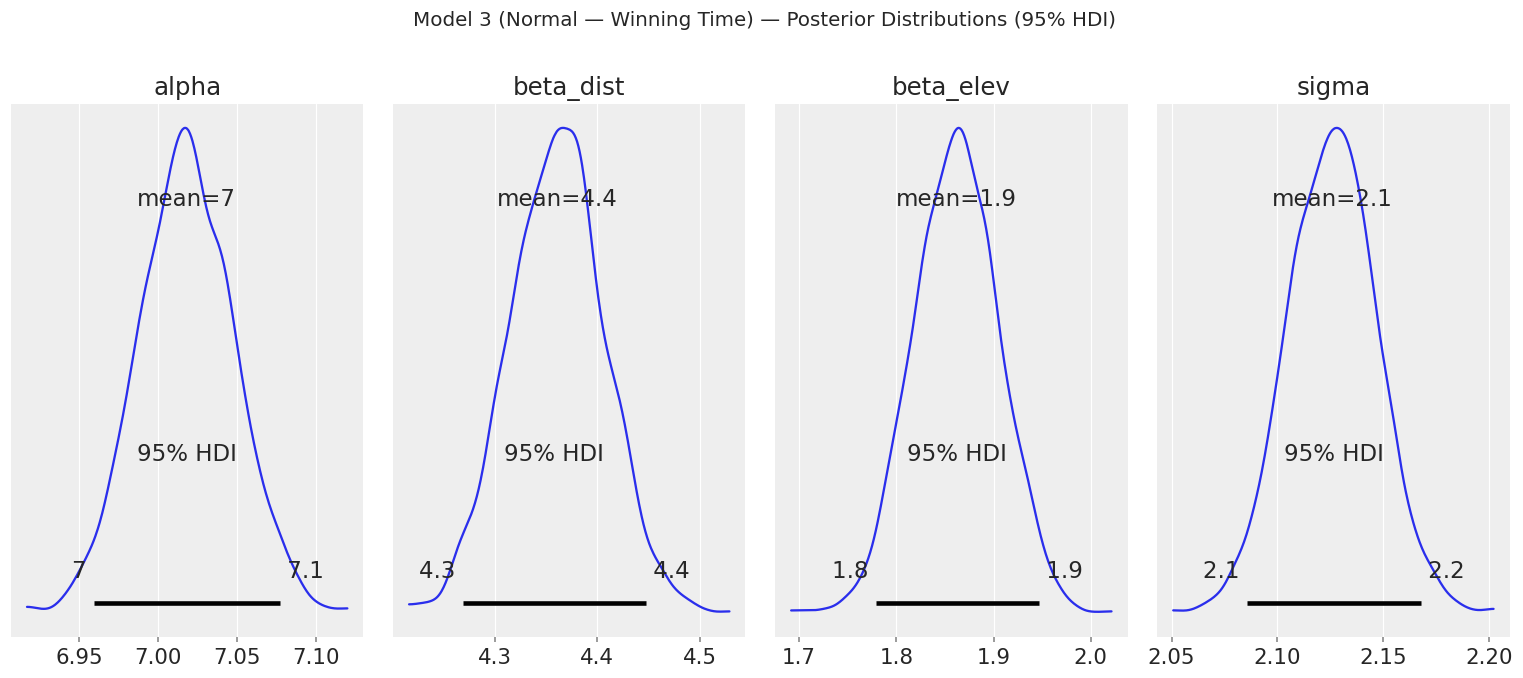

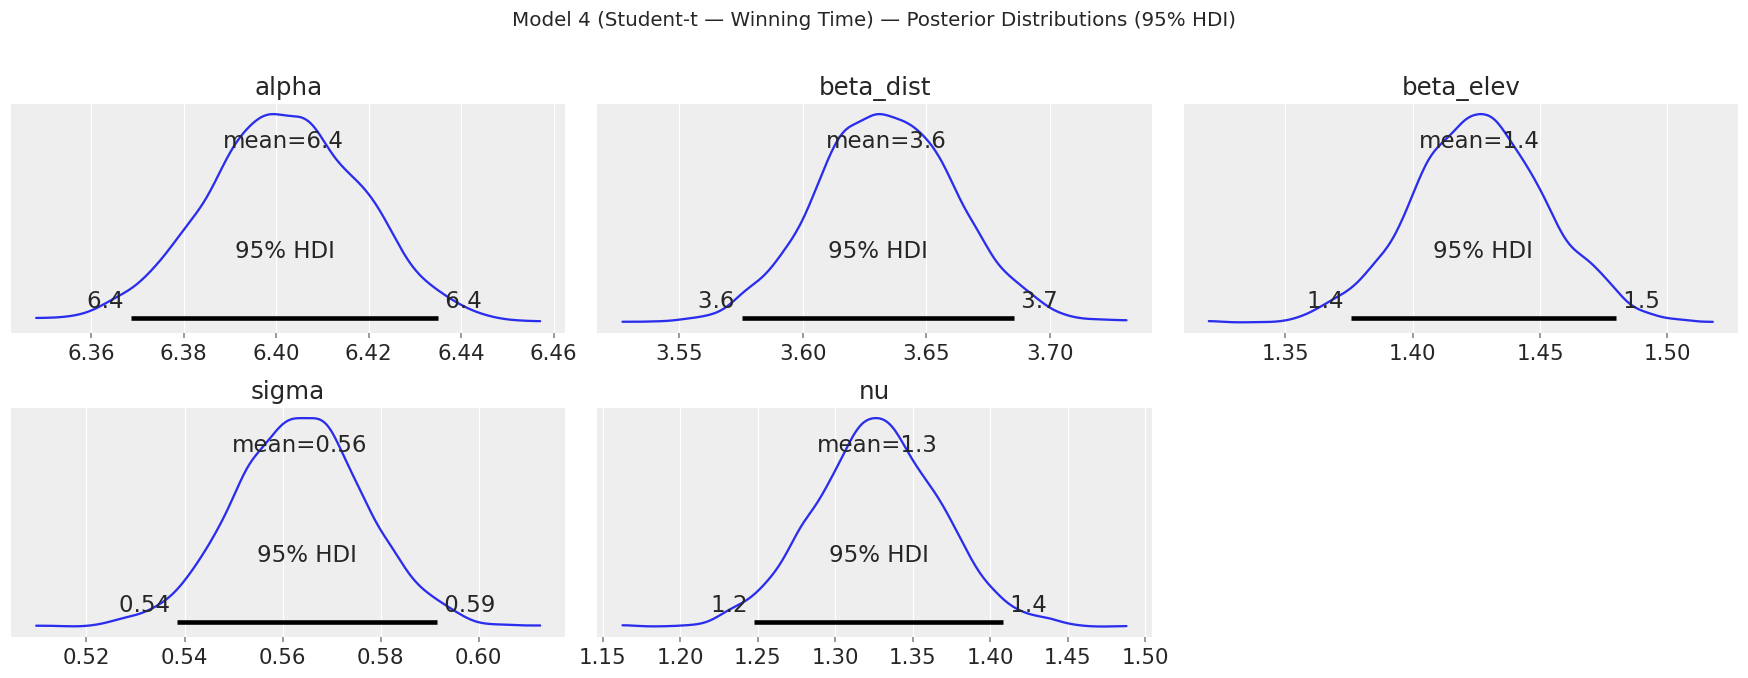

In [15]:
# Posterior marginal distributions — Model 3
fig = az.plot_posterior(idata3, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma'],
                        figsize=(14, 6), hdi_prob=0.95)
plt.suptitle('Model 3 (Normal — Winning Time) — Posterior Distributions (95% HDI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_wt_09_model3_posteriors.png', bbox_inches='tight')
plt.show()

# Posterior marginal distributions — Model 4
fig = az.plot_posterior(idata4, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'],
                        figsize=(16, 6), hdi_prob=0.95)
plt.suptitle('Model 4 (Student-t — Winning Time) — Posterior Distributions (95% HDI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_wt_10_model4_posteriors.png', bbox_inches='tight')
plt.show()

In [16]:
# Parameter interpretation
print("=" * 70)
print("PARAMETER INTERPRETATION — Winning Time Models")
print("=" * 70)

dist_mean = df_full['Distance'].mean()
dist_std = df_full['Distance'].std()
elev_mean = df_full['Elevation Gain'].mean()
elev_std = df_full['Elevation Gain'].std()

for name, idata, params in [("Model 3 (Normal)", idata3, ['alpha', 'beta_dist', 'beta_elev', 'sigma']),
                              ("Model 4 (Student-t)", idata4, ['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'])]:
    print(f"\n{'─'*70}")
    print(f"  {name}")
    print(f"{'─'*70}")
    for p in params:
        samples = idata.posterior[p].values.flatten()
        print(f"\n  {p}:")
        print(f"    Mean: {samples.mean():.3f}")
        print(f"    95% HDI: [{np.percentile(samples, 2.5):.3f}, {np.percentile(samples, 97.5):.3f}]")
        if p == 'alpha':
            print(f"    → Expected winning time at average distance ({dist_mean:.0f}km) and elevation ({elev_mean:.0f}m)")
        elif p == 'beta_dist':
            print(f"    → Per 10km: {samples.mean()/dist_std*10:.2f}h")
        elif p == 'beta_elev':
            print(f"    → Per 1000m elevation: {samples.mean()/elev_std*1000:.2f}h")
        elif p == 'sigma':
            print(f"    → Residual variability in winning time")
        elif p == 'nu':
            print(f"    → Degrees of freedom (lower = heavier tails, ∞ = Normal)")
            if samples.mean() < 2:
                print(f"    → ν < 2: Variance undefined — very heavy tails!")

# Compare sigma between models
sigma3 = idata3.posterior['sigma'].values.flatten()
sigma4 = idata4.posterior['sigma'].values.flatten()
print(f"\n\n{'='*70}")
print(f"SIGMA COMPARISON")
print(f"{'='*70}")
print(f"  Model 3 (Normal) σ:    {sigma3.mean():.3f}h")
print(f"  Model 4 (Student-t) σ: {sigma4.mean():.3f}h")
print(f"  Reduction: {(1 - sigma4.mean()/sigma3.mean())*100:.1f}%")
print(f"  → Student-t model achieves lower σ by handling outliers via heavy tails")

PARAMETER INTERPRETATION — Winning Time Models

──────────────────────────────────────────────────────────────────────
  Model 3 (Normal)
──────────────────────────────────────────────────────────────────────

  alpha:
    Mean: 7.018
    95% HDI: [6.959, 7.077]
    → Expected winning time at average distance (60km) and elevation (2518m)

  beta_dist:
    Mean: 4.361
    95% HDI: [4.271, 4.451]
    → Per 10km: 1.08h

  beta_elev:
    Mean: 1.862
    95% HDI: [1.778, 1.946]
    → Per 1000m elevation: 1.00h

  sigma:
    Mean: 2.126
    95% HDI: [2.085, 2.168]
    → Residual variability in winning time

──────────────────────────────────────────────────────────────────────
  Model 4 (Student-t)
──────────────────────────────────────────────────────────────────────

  alpha:
    Mean: 6.402
    95% HDI: [6.368, 6.434]
    → Expected winning time at average distance (60km) and elevation (2518m)

  beta_dist:
    Mean: 3.634
    95% HDI: [3.578, 3.690]
    → Per 10km: 0.90h

  beta_elev:
  

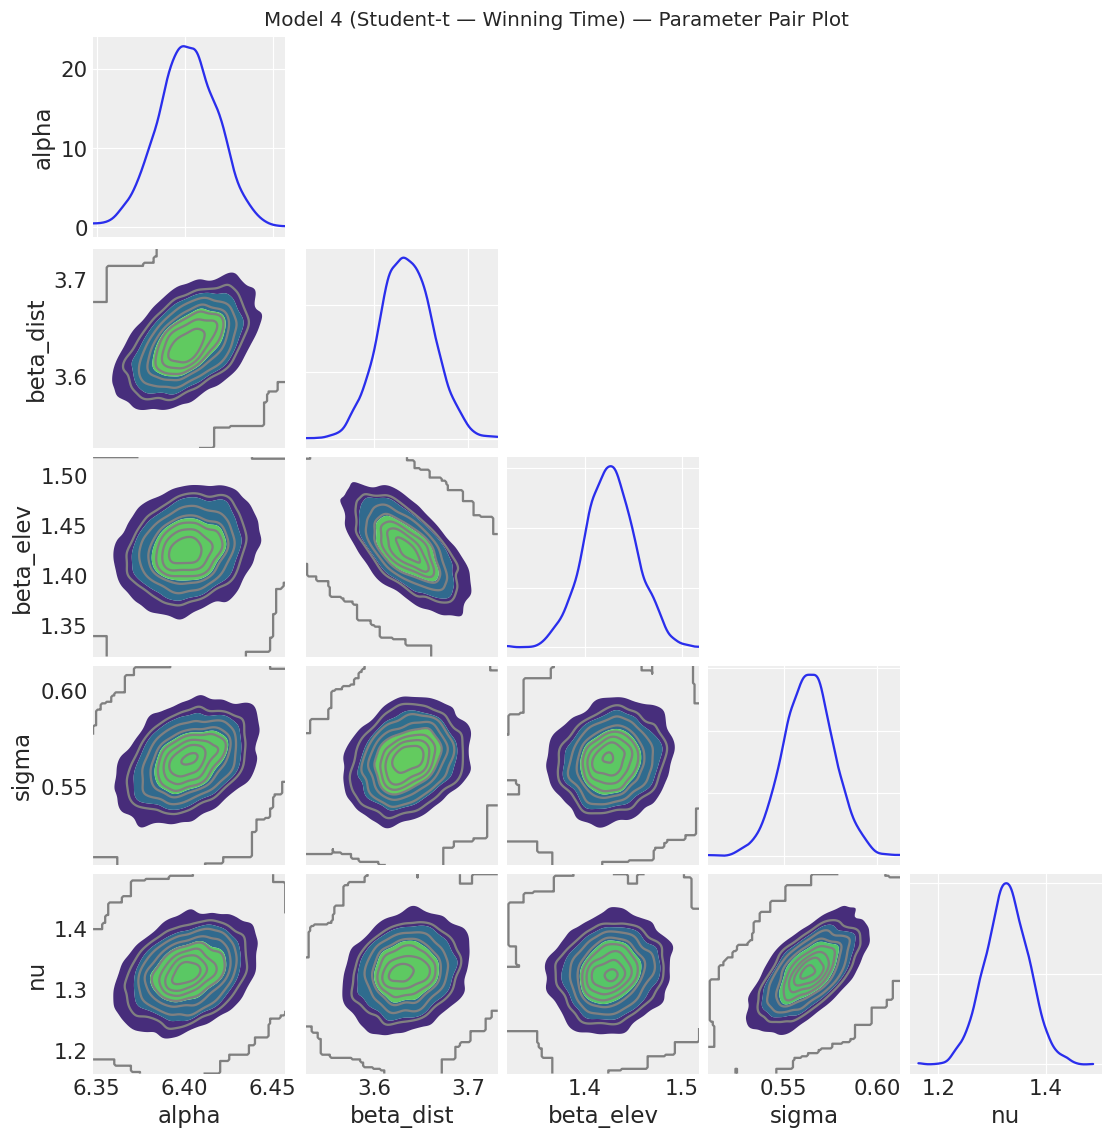

In [17]:
# Pair plots
fig = az.plot_pair(idata4, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'],
                   kind='kde', figsize=(10, 10), marginals=True)
plt.suptitle('Model 4 (Student-t — Winning Time) — Parameter Pair Plot', fontsize=13, y=1.02)
plt.savefig('fig_wt_11_pairs.png', bbox_inches='tight')
plt.show()

## 7. Model Comparison

We compare models using:
1. **LOO-CV** (Leave-One-Out Cross-Validation via Pareto-smoothed importance sampling)
2. **WAIC** (Widely Applicable Information Criterion)
3. **Pareto-k diagnostics** (reliability of LOO estimates)

In [18]:
# LOO-CV comparison
loo3 = az.loo(idata3, pointwise=True)
loo4 = az.loo(idata4, pointwise=True)

print("=" * 70)
print("LOO-CV COMPARISON — Winning Time Models")
print("=" * 70)
print(f"\nModel 3 (Normal):    ELPD = {loo3.elpd_loo:.1f} (SE = {loo3.se:.1f})")
print(f"Model 4 (Student-t): ELPD = {loo4.elpd_loo:.1f} (SE = {loo4.se:.1f})")

elpd_diff = loo4.elpd_loo - loo3.elpd_loo
print(f"\nELPD difference (Model 4 - Model 3): {elpd_diff:.1f}")

# Formal comparison
loo_compare = az.compare({'Model 3 (Normal)': idata3, 'Model 4 (Student-t)': idata4})
print(f"\nArviZ LOO comparison:")
print(loo_compare.to_string())

LOO-CV COMPARISON — Winning Time Models

Model 3 (Normal):    ELPD = -10877.6 (SE = 181.3)
Model 4 (Student-t): ELPD = -8384.0 (SE = 106.3)

ELPD difference (Model 4 - Model 3): 2493.6

ArviZ LOO comparison:
                     rank      elpd_loo      p_loo    elpd_diff    weight          se         dse  warning scale
Model 4 (Student-t)     0  -8384.030552   8.734166     0.000000  0.854135  106.264058    0.000000    False   log
Model 3 (Normal)        1 -10877.598427  23.579637  2493.567875  0.145865  181.301657  155.080451    False   log


WAIC COMPARISON — Winning Time Models

Model 3 (Normal):    WAIC = -10877.6 (SE = 181.3)
Model 4 (Student-t): WAIC = -8384.0 (SE = 106.3)

WAIC difference (Model 4 - Model 3): 2493.5


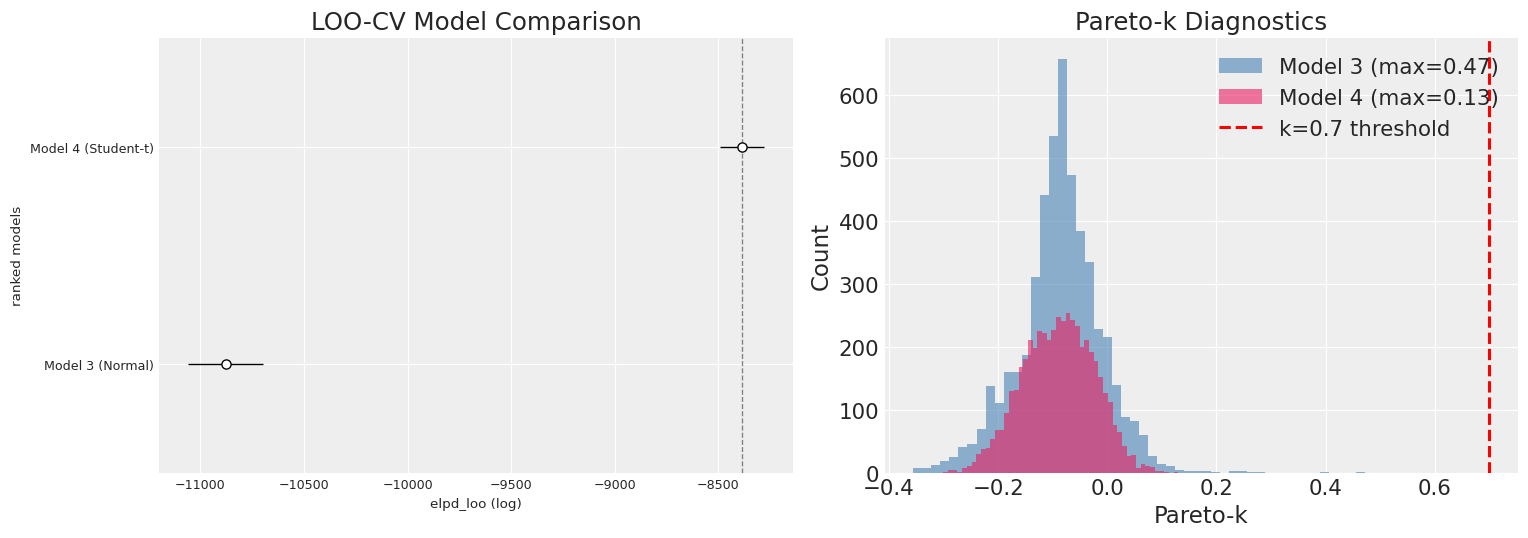


PARETO-K DIAGNOSTICS

Model 3 (Normal):
  k < 0.5 (good):       5000 (100.0%)
  0.5 < k < 0.7 (ok):   0 (0.0%)
  k > 0.7 (bad):        0 (0.0%)

Model 4 (Student-t):
  k < 0.5 (good):       5000 (100.0%)
  0.5 < k < 0.7 (ok):   0 (0.0%)
  k > 0.7 (bad):        0 (0.0%)


In [19]:
# WAIC comparison
waic3 = az.waic(idata3, pointwise=True)
waic4 = az.waic(idata4, pointwise=True)

print("=" * 70)
print("WAIC COMPARISON — Winning Time Models")
print("=" * 70)
print(f"\nModel 3 (Normal):    WAIC = {waic3.elpd_waic:.1f} (SE = {waic3.se:.1f})")
print(f"Model 4 (Student-t): WAIC = {waic4.elpd_waic:.1f} (SE = {waic4.se:.1f})")
print(f"\nWAIC difference (Model 4 - Model 3): {waic4.elpd_waic - waic3.elpd_waic:.1f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

az.plot_compare(loo_compare, ax=axes[0])
axes[0].set_title('LOO-CV Model Comparison')

# Pareto-k values
pareto_k3 = loo3.pareto_k.values
pareto_k4 = loo4.pareto_k.values

axes[1].hist(pareto_k3, bins=50, alpha=0.6, color='steelblue', label=f'Model 3 (max={pareto_k3.max():.2f})')
axes[1].hist(pareto_k4, bins=50, alpha=0.6, color='#E91E63', label=f'Model 4 (max={pareto_k4.max():.2f})')
axes[1].axvline(0.7, color='red', linestyle='--', linewidth=2, label='k=0.7 threshold')
axes[1].set_xlabel('Pareto-k')
axes[1].set_ylabel('Count')
axes[1].set_title('Pareto-k Diagnostics')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_wt_12_model_comparison.png', bbox_inches='tight')
plt.show()

# Pareto-k summary
print(f"\n{'='*70}")
print("PARETO-K DIAGNOSTICS")
print(f"{'='*70}")
for name, pk in [("Model 3 (Normal)", pareto_k3), ("Model 4 (Student-t)", pareto_k4)]:
    print(f"\n{name}:")
    print(f"  k < 0.5 (good):       {(pk < 0.5).sum()} ({(pk < 0.5).mean()*100:.1f}%)")
    print(f"  0.5 < k < 0.7 (ok):   {((pk >= 0.5) & (pk < 0.7)).sum()} ({((pk >= 0.5) & (pk < 0.7)).mean()*100:.1f}%)")
    print(f"  k > 0.7 (bad):        {(pk >= 0.7).sum()} ({(pk >= 0.7).mean()*100:.1f}%)")

## 8. Final Assessment

In [20]:
# Final comprehensive summary
print("=" * 70)
print("FINAL ASSESSMENT — Bayesian Workflow for Winning Time")
print("=" * 70)

# Extract key posteriors
alpha3 = idata3.posterior['alpha'].values.flatten()
beta_dist3 = idata3.posterior['beta_dist'].values.flatten()
beta_elev3 = idata3.posterior['beta_elev'].values.flatten()
sigma3_post = idata3.posterior['sigma'].values.flatten()

alpha4 = idata4.posterior['alpha'].values.flatten()
beta_dist4 = idata4.posterior['beta_dist'].values.flatten()
beta_elev4 = idata4.posterior['beta_elev'].values.flatten()
sigma4_post = idata4.posterior['sigma'].values.flatten()
nu4 = idata4.posterior['nu'].values.flatten()

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    MODEL COMPARISON SUMMARY                          │
├─────────────────────┬────────────────────┬──────────────────────────┤
│ Parameter           │ Model 3 (Normal)   │ Model 4 (Student-t)      │
├─────────────────────┼────────────────────┼──────────────────────────┤
│ α (intercept)       │ {alpha3.mean():>8.3f} h         │ {alpha4.mean():>8.3f} h                │
│ β_dist              │ {beta_dist3.mean():>8.3f} h/SD      │ {beta_dist4.mean():>8.3f} h/SD             │
│ β_elev              │ {beta_elev3.mean():>8.3f} h/SD      │ {beta_elev4.mean():>8.3f} h/SD             │
│ σ                   │ {sigma3_post.mean():>8.3f} h         │ {sigma4_post.mean():>8.3f} h                │
│ ν                   │      — (∞)         │ {nu4.mean():>8.2f}                  │
├─────────────────────┼────────────────────┼──────────────────────────┤
│ LOO ELPD            │ {loo3.elpd_loo:>10.1f}       │ {loo4.elpd_loo:>10.1f}               │
│ WAIC ELPD           │ {waic3.elpd_waic:>10.1f}       │ {waic4.elpd_waic:>10.1f}               │
│ Pareto-k > 0.7      │ {(pareto_k3 >= 0.7).sum():>10d}       │ {(pareto_k4 >= 0.7).sum():>10d}               │
└─────────────────────┴────────────────────┴──────────────────────────┘
""")

# Winner determination
winner = "Model 4 (Student-t)" if loo4.elpd_loo > loo3.elpd_loo else "Model 3 (Normal)"
print(f"\n🏆 WINNER: {winner}")
print(f"\n   ELPD difference: {abs(elpd_diff):.1f}")
print(f"   σ reduction: {(1 - sigma4_post.mean()/sigma3_post.mean())*100:.1f}%")
print(f"   ν posterior: {nu4.mean():.2f} (95% HDI: [{np.percentile(nu4, 2.5):.2f}, {np.percentile(nu4, 97.5):.2f}])")

if nu4.mean() < 2:
    print(f"\n   ⚠ ν < 2: The winning time data has extremely heavy tails")
    print(f"     (undefined variance under the Student-t distribution)")
elif nu4.mean() < 5:
    print(f"\n   Heavy tails confirmed (ν < 5): Outlier races substantially affect the Normal model")
elif nu4.mean() < 30:
    print(f"\n   Moderate tails: Some benefit from the Student-t model")
else:
    print(f"\n   ν is large: Data are approximately Normal, little benefit from Student-t")

print(f"\n\nCONCLUSION:")
print(f"  The Bayesian workflow for Winning Time follows the same pattern as Mean Finish Time.")
print(f"  Distance is the dominant predictor of winning time, with elevation gain")
print(f"  contributing a secondary but meaningful effect.")
print(f"  The Student-t model is preferred due to heavy-tailed residuals in the data —")
print(f"  outlier races where winners took much longer than expected are better")
print(f"  accommodated without inflating σ for all predictions.")

FINAL ASSESSMENT — Bayesian Workflow for Winning Time

┌─────────────────────────────────────────────────────────────────────┐
│                    MODEL COMPARISON SUMMARY                          │
├─────────────────────┬────────────────────┬──────────────────────────┤
│ Parameter           │ Model 3 (Normal)   │ Model 4 (Student-t)      │
├─────────────────────┼────────────────────┼──────────────────────────┤
│ α (intercept)       │    7.018 h         │    6.402 h                │
│ β_dist              │    4.361 h/SD      │    3.634 h/SD             │
│ β_elev              │    1.862 h/SD      │    1.426 h/SD             │
│ σ                   │    2.126 h         │    0.563 h                │
│ ν                   │      — (∞)         │     1.33                  │
├─────────────────────┼────────────────────┼──────────────────────────┤
│ LOO ELPD            │   -10877.6       │    -8384.0               │
│ WAIC ELPD           │   -10877.6       │    -8384.0               │
│ Paret